# UA2 - Primera clase, vision por Computador 1 (PIL + Matplotlib)

Notebook de clase con **ejercicios por FASES** (sin NumPy).

**Requisitos** (ejecutar una sola vez si hace falta):
```bash
pip install pillow matplotlib
```
**Sugerencia:** Trabaja de arriba hacia abajo. Cada bloque está dividido en fases cortas.


## Preparacion
Genera las **imágenes de ejemplo** (sintéticas) para usar en todos los ejercicios.
Esto garantiza que todos tengamos una imagen adecuada y reproducible.


In [1]:
# Generador de imagen 'UA2_vision_example.png' (formas, patrones, gradiente, diana)
from PIL import Image, ImageDraw, ImageFont
import math

W, H = 1000, 700
bg_color = (245, 245, 245)
img = Image.new("RGB", (W, H), bg_color)
draw = ImageDraw.Draw(img)
font = ImageFont.load_default()

# Rejilla
grid_step = 50
for x in range(0, W, grid_step):
    draw.line([(x, 0), (x, H)], fill=(230, 230, 230), width=1)
for y in range(0, H, grid_step):
    draw.line([(0, y), (W, y)], fill=(230, 230, 230), width=1)

# Cabecera
title = "UA2 - Vision por Computador - PIL + Matplotlib"
draw.rectangle([0, 0, W, 60], fill=(255, 255, 255))
draw.text((20, 20), title, fill=(0, 0, 0), font=font)

# Formas RGB
draw.rectangle([40, 100, 260, 260], fill=(220, 50, 50), outline=(0, 0, 0), width=2)
draw.ellipse([300, 100, 460, 260], fill=(50, 200, 80), outline=(0, 0, 0), width=2)
triangle = [(150, 300), (250, 520), (50, 520)]
draw.polygon(triangle, fill=(60, 100, 220), outline=(0, 0, 0))

def star_points(cx, cy, r_outer=80, r_inner=35, num_points=5):
    pts = []
    for i in range(num_points*2):
        angle = (math.pi/2) + i * math.pi / num_points
        r = r_outer if i % 2 == 0 else r_inner
        x = cx + r * math.cos(angle)
        y = cy - r * math.sin(angle)
        pts.append((x, y))
    return pts

draw.polygon(star_points(360, 420), fill=(240, 200, 40), outline=(0, 0, 0))

# Checkerboard
cb_x, cb_y = 520, 100
cb_tiles = 10
tile_size = 16
for i in range(cb_tiles):
    for j in range(cb_tiles):
        color = (255, 255, 255) if (i + j) % 2 == 0 else (30, 30, 30)
        x0 = cb_x + i * tile_size
        y0 = cb_y + j * tile_size
        draw.rectangle([x0, y0, x0 + tile_size, y0 + tile_size], fill=color)
draw.rectangle([cb_x, cb_y, cb_x + cb_tiles*tile_size, cb_y + cb_tiles*tile_size],
               outline=(0, 0, 0), width=2)

# Barras tipo codigo de barras
bar_x0, bar_y0 = 720, 100
bar_w, bar_h = 200, 160
stripe_w = 8
for x in range(bar_x0, bar_x0 + bar_w, stripe_w):
    fill = (0, 0, 0) if ((x - bar_x0) // stripe_w) % 2 == 0 else (255, 255, 255)
    draw.rectangle([x, bar_y0, x + stripe_w - 1, bar_y0 + bar_h], fill=fill)
draw.rectangle([bar_x0, bar_y0, bar_x0 + bar_w, bar_y0 + bar_h], outline=(0, 0, 0), width=2)

# Gradiente gris
grad_x0, grad_y0 = 520, 300
grad_w, grad_h = 400, 60
for dx in range(grad_w):
    val = int(255 * dx / (grad_w - 1))
    draw.line([(grad_x0 + dx, grad_y0), (grad_x0 + dx, grad_y0 + grad_h)], fill=(val, val, val))
draw.rectangle([grad_x0, grad_y0, grad_x0 + grad_w, grad_y0 + grad_h], outline=(0, 0, 0), width=2)
draw.text((grad_x0, grad_y0 - 16), "Gradiente en escala de grises (0 a 255)", fill=(0, 0, 0), font=font)

# Diana concentric
cx, cy = 780, 480
for r in range(120, 0, -20):
    color = (20, 20, 20) if (r // 20) % 2 == 0 else (230, 230, 230)
    draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=color, outline=(0, 0, 0))

# Flechas orientacion
def arrow_right(x, y, w=120, h=24, color=(0, 0, 0)):
    rect = [x, y - h//2, x + w - h, y + h//2]
    head = [(x + w - h, y - h//2), (x + w, y), (x + w - h, y + h//2)]
    draw.rectangle(rect, fill=color)
    draw.polygon(head, fill=color)

def arrow_up(x, y, w=24, h=120, color=(0, 0, 0)):
    rect = [x - w//2, y - h + w, x + w//2, y]
    head = [(x - w//2, y - h + w), (x, y - h), (x + w//2, y - h + w)]
    draw.rectangle(rect, fill=color)
    draw.polygon(head, fill=color)

arrow_right(60, 620, w=160, h=26, color=(0, 0, 0))
draw.text((230, 610), "-> eje X", fill=(0, 0, 0), font=font)
arrow_up(420, 640, w=26, h=160, color=(0, 0, 0))
draw.text((430, 620), "^ eje Y", fill=(0, 0, 0), font=font)

# Etiquetas
draw.text((60, 80), "Formas RGB", fill=(0, 0, 0), font=font)
draw.text((520, 80), "Patrones (checker y barras)", fill=(0, 0, 0), font=font)
draw.text((700, 280), "Gradiente gris", fill=(0, 0, 0), font=font)
draw.text((730, 620), "Diana concentrica", fill=(0, 0, 0), font=font)

img.save("UA2_vision_example.png", format="PNG", optimize=True)
print("Generado: UA2_vision_example.png")


Generado: UA2_vision_example.png


In [2]:
# Generador de imagen 'UA2_landscape_example.jpg' (paisaje colorido)
from PIL import Image, ImageDraw, ImageFont
import math, random

def lerp(a, b, t):
    return int(a + (b - a) * t)

W, H = 1200, 800
img = Image.new("RGB", (W, H), (135, 206, 235))
draw = ImageDraw.Draw(img)
font = ImageFont.load_default()

# Cielo gradiente
sky_top = (20, 60, 160)
sky_bottom = (180, 220, 255)
sky_h = 360
for y in range(sky_h):
    t = y / max(1, sky_h - 1)
    col = (lerp(sky_top[0], sky_bottom[0], t),
           lerp(sky_top[1], sky_bottom[1], t),
           lerp(sky_top[2], sky_bottom[2], t))
    draw.line([(0, y), (W, y)], fill=col)

# Sol
sun_cx, sun_cy, sun_r = 980, 120, 60
for r, c in [(90, (255, 235, 150)), (75, (255, 225, 120)), (60, (255, 210, 80)), (45, (255, 195, 60))]:
    draw.ellipse([sun_cx - r, sun_cy - r, sun_cx + r, sun_cy + r], fill=c)

# Nubes
def draw_cloud(x, y, scale=1.0):
    parts = [(0,0,120,60),(60,-10,140,70),(-40,10,110,70),(100,5,180,65)]
    for (dx1, dy1, dx2, dy2) in parts:
        bbox = [x+int(dx1*scale), y+int(dy1*scale), x+int(dx2*scale), y+int(dy2*scale)]
        draw.ellipse(bbox, fill=(255,255,255))

draw_cloud(160, 80, 1.1)
draw_cloud(420, 60, 0.9)
draw_cloud(700, 90, 1.2)

# Montanas
def draw_mountain_peak(cx, base_y, width, height, color):
    pts = [(cx - width//2, base_y), (cx + width//2, base_y), (cx, base_y - height)]
    draw.polygon(pts, fill=color, outline=(0,0,0))

draw_mountain_peak(250, 460, 380, 220, (90, 110, 160))
draw_mountain_peak(520, 460, 420, 240, (80, 100, 150))
draw_mountain_peak(850, 460, 360, 210, (70, 90, 140))
draw_mountain_peak(380, 520, 420, 220, (100, 120, 100))
draw_mountain_peak(700, 520, 460, 240, (95, 115, 95))

# Colinas
draw.ellipse([-200, 420, 500, 820], fill=(60, 160, 70), outline=(0,0,0))
draw.ellipse([200, 430, 1000, 860], fill=(50, 145, 60), outline=(0,0,0))
draw.ellipse([800, 440, 1500, 880], fill=(45, 135, 55), outline=(0,0,0))

# Lago
lake_y1, lake_y2 = 540, 650
lake_left, lake_right = 120, 1080
lake_col_left = (20, 120, 180)
lake_col_right = (120, 200, 230)
for x in range(lake_left, lake_right):
    t = (x - lake_left) / max(1, (lake_right - lake_left - 1))
    col = (lerp(lake_col_left[0], lake_col_right[0], t),
           lerp(lake_col_left[1], lake_col_right[1], t),
           lerp(lake_col_left[2], lake_col_right[2], t))
    draw.line([(x, lake_y1), (x, lake_y2)], fill=col)
draw.rectangle([lake_left, lake_y1, lake_right, lake_y2], outline=(0,0,0), width=2)

# Ondas
cx, cy = (lake_left + lake_right)//2, (lake_y1 + lake_y2)//2
for r in range(40, 360, 40):
    draw.ellipse([cx - r, cy - r//4, cx + r, cy + r//4], outline=(240, 240, 255))

# Pradera
draw.rectangle([0, 650, W, H], fill=(70, 170, 80))

# Sendero
path = [(560, 800), (640, 800), (700, 740), (660, 700), (680, 660), (640, 630)]
draw.polygon(path, fill=(210, 190, 160), outline=(120, 100, 80))

# Arboles
def draw_tree(x, y, scale=1.0):
    trunk_w, trunk_h = int(14*scale), int(40*scale)
    draw.rectangle([x - trunk_w//2, y - trunk_h, x + trunk_w//2, y], fill=(110, 70, 40), outline=(0,0,0))
    r1, r2, r3 = int(24*scale), int(30*scale), int(20*scale)
    draw.ellipse([x - r2, y - trunk_h - r2 - 6, x + r2, y - trunk_h + r2 - 6], fill=(35, 120, 55), outline=(0,0,0))
    draw.ellipse([x - r1 - 18, y - trunk_h - r1 + 6, x + r1 - 18, y - trunk_h + r1 + 6], fill=(30, 110, 50), outline=(0,0,0))
    draw.ellipse([x - r3 + 24, y - trunk_h - r3 + 12, x + r3 + 24, y - trunk_h + r3 + 12], fill=(40, 130, 60), outline=(0,0,0))

for tx in [160, 220, 300, 360, 980, 1040, 1120]:
    draw_tree(tx, 650, scale=1.0 + (tx % 3)*0.15)

# Casa
house_x, house_y = 880, 600
draw.rectangle([house_x, house_y - 80, house_x + 120, house_y], fill=(245, 220, 150), outline=(0,0,0))
draw.polygon([(house_x - 10, house_y - 80), (house_x + 60, house_y - 130), (house_x + 130, house_y - 80)], fill=(200, 50, 50), outline=(0,0,0))
draw.rectangle([house_x + 50, house_y - 40, house_x + 80, house_y], fill=(120, 70, 40), outline=(0,0,0))
draw.rectangle([house_x + 10, house_y - 60, house_x + 40, house_y - 35], fill=(80, 140, 210), outline=(0,0,0))
draw.rectangle([house_x + 85, house_y - 60, house_x + 115, house_y - 35], fill=(80, 140, 210), outline=(0,0,0))

# Flores
palette = [(230, 70, 90), (240, 180, 60), (250, 230, 70), (120, 200, 80),
           (70, 160, 220), (150, 120, 220), (240, 120, 200), (70, 210, 180)]
for _ in range(140):
    fx = random.randint(60, 540)
    fy = random.randint(660, 790)
    r = random.randint(3, 6)
    col = random.choice(palette)
    draw.ellipse([fx - r, fy - r, fx + r, fy + r], fill=col, outline=(0,0,0))

# Parches de texturas
cb_x, cb_y = 80, 560
tiles, size = 8, 14
for i in range(tiles):
    for j in range(tiles):
        color = (255,255,255) if (i + j) % 2 == 0 else (30,30,30)
        x0 = cb_x + i*size
        y0 = cb_y + j*size
        draw.rectangle([x0, y0, x0 + size, y0 + size], fill=color)
draw.rectangle([cb_x, cb_y, cb_x + tiles*size, cb_y + tiles*size], outline=(0,0,0))

sx0, sy0, sw, sh = 240, 560, 120, 112
stripe_w = 6
for x in range(sx0, sx0 + sw, stripe_w):
    fill = (20, 20, 20) if ((x - sx0)//stripe_w) % 2 == 0 else (240, 240, 240)
    draw.rectangle([x, sy0, x + stripe_w - 1, sy0 + sh], fill=fill)
draw.rectangle([sx0, sy0, sx0 + sw, sy0 + sh], outline=(0,0,0))

draw.text((16, 12), "UA2 Landscape - PIL + Matplotlib", fill=(0,0,0), font=font)

img.save("UA2_landscape_example.jpg", format="JPEG", quality=92, subsampling="4:2:0", optimize=True)
print("Generado: UA2_landscape_example.jpg")


Generado: UA2_landscape_example.jpg


In [1]:
# Elegir la imagen por defecto para los ejercicios
IMG_PATH = "pasta.png"  # cambia por "UA2_landscape_example.jpg" si prefieres
print("Usando IMG_PATH =", IMG_PATH)


Usando IMG_PATH = pasta.png


## Bloque 1 — Cargar y visualizar (por FASES)

In [2]:
# FASE 1: Definir ruta y abrir imagen
from PIL import Image
import matplotlib.pyplot as plt
img_color = Image.open ("./pasta.jpg")
print("Modo:", img_color.mode)
print("Tamaño:", img_color.size)




Modo: RGB
Tamaño: (1429, 1905)


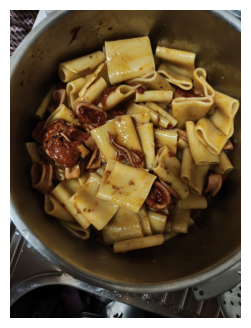

In [3]:
# FASE 2: Mostrar la imagen tal cual
plt.figure(figsize=(4,4))
plt.imshow(img_color)
plt.axis("off")
plt.show()


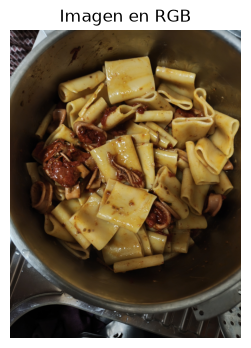

In [4]:
# FASE 3: Convertir a RGB y mostrar
img_rgb = img_color.convert("RGB")
plt.figure(figsize=(4,4))
plt.title("Imagen en RGB")
plt.axis("off")
plt.imshow(img_rgb)



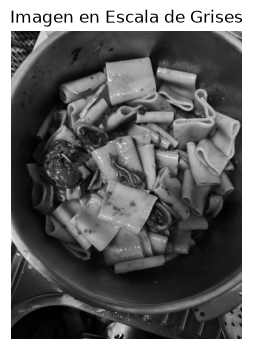

In [5]:
# FASE 4: Escala de grises y mostrar
img_gray = img_color.convert("L")
plt.figure(figsize=(4,4))
plt.title("Imagen en Escala de Grises")
plt.imshow(img_gray, cmap="gray")
plt.axis("off")
plt.show()


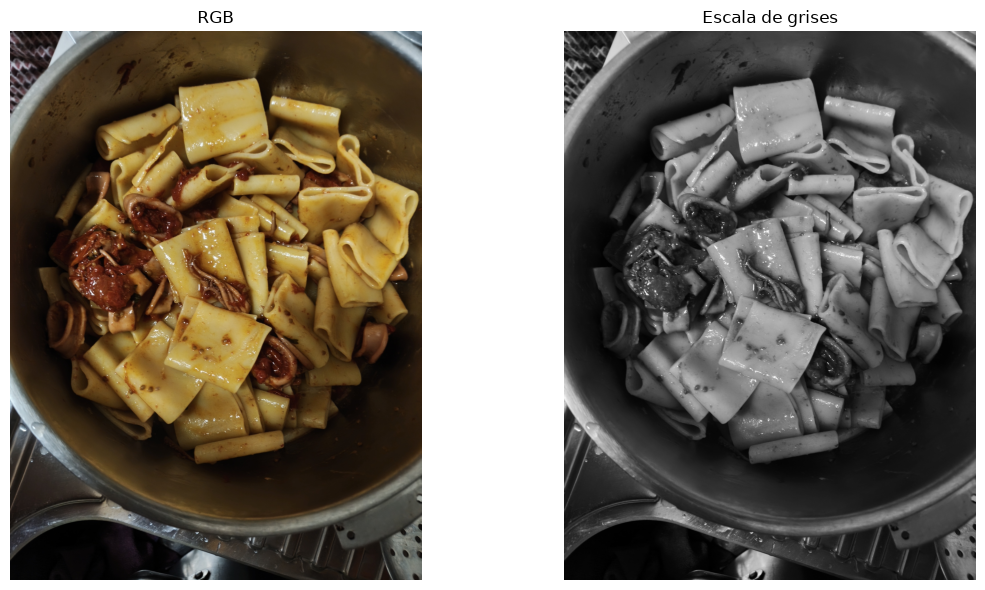

In [6]:
# FASE 5: Comparar RGB vs GRAY en una figura con 2 paneles

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.imshow(img_rgb)
ax1.set_title("RGB")
ax1.axis("off")

ax2.imshow(img_gray, cmap="gray")
ax2.set_title("Escala de grises")
ax2.axis("off")

plt.tight_layout()

plt.show()

## Bloque 2 — Canales y histogramas (sin NumPy)

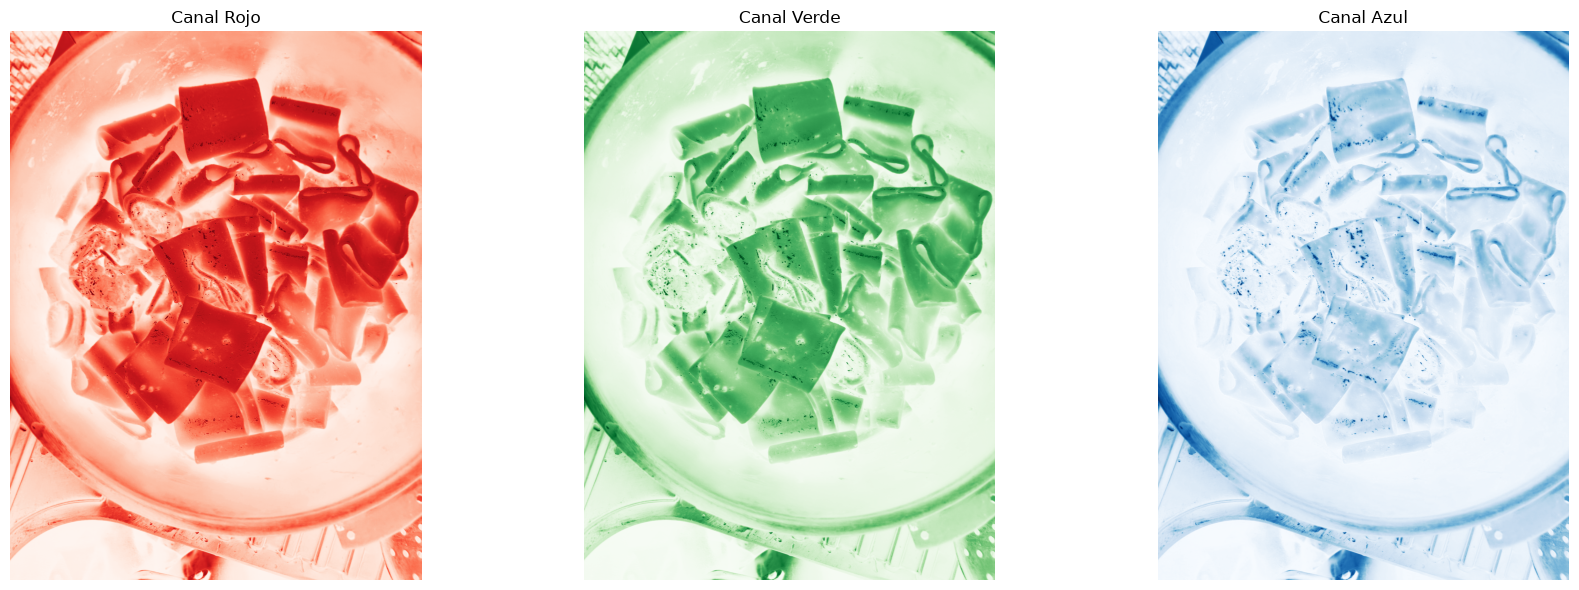

In [9]:
# FASE 1: Separar canales y mostrarlos

w, h = img_color.size

r = Image.new("L", (w, h))
g = Image.new("L", (w, h))
b = Image.new("L", (w, h))

pixels = img_color.load()
for y in range(h):
    for x in range(w):
        red, green, blue = pixels[x, y]
        r.putpixel((x, y), red)
        g.putpixel((x, y), green)
        b.putpixel((x, y), blue)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

ax1.imshow(r, cmap="Reds")
ax1.set_title("Canal Rojo")
ax1.axis("off")

ax2.imshow(g, cmap="Greens")
ax2.set_title("Canal Verde")
ax2.axis("off")

ax3.imshow(b, cmap="Blues")
ax3.set_title("Canal Azul")
ax3.axis("off")

plt.tight_layout()

plt.show()

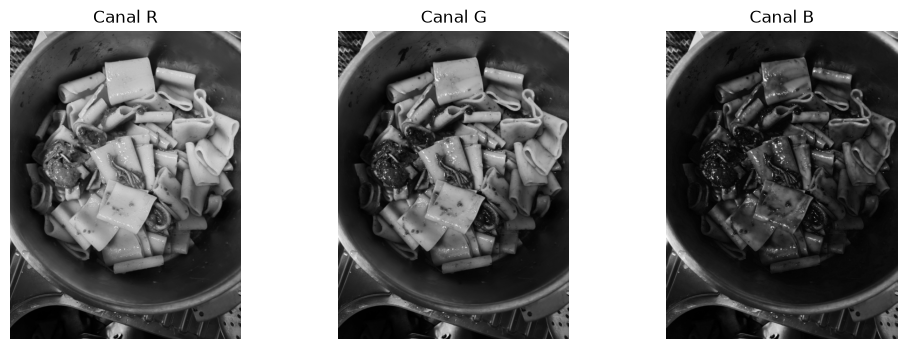

In [11]:
# Alternative in greyscale

r, g, b = img_color.split()
# plt.figure(figsize=(4,4)); plt.imshow(r, cmap="gray"); plt.title("Canal R"); plt.axis("off"); plt.show()
# plt.figure(figsize=(4,4)); plt.imshow(g, cmap="gray"); plt.title("Canal G"); plt.axis("off"); plt.show()
# plt.figure(figsize=(4,4)); plt.imshow(b, cmap="gray"); plt.title("Canal B"); plt.axis("off"); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(r, cmap="gray"); axes[0].set_title("Canal R")
axes[1].imshow(g, cmap="gray"); axes[1].set_title("Canal G")
axes[2].imshow(b, cmap="gray"); axes[2].set_title("Canal B")

for ax in axes:
    ax.axis("off")

plt.show()


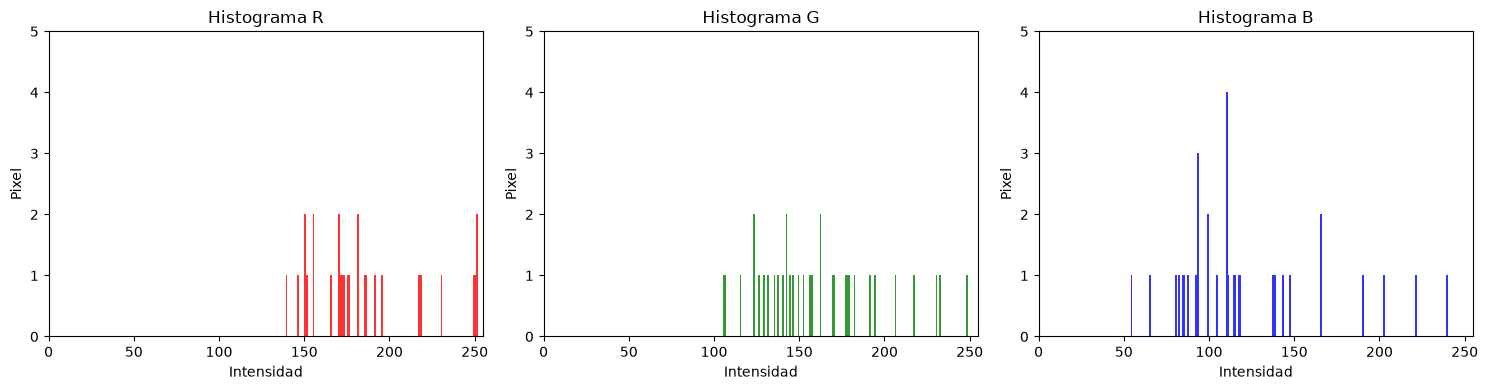

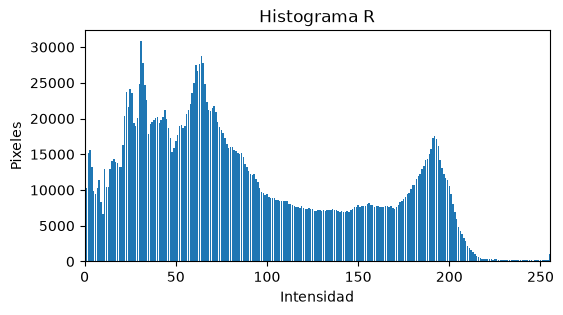

In [24]:
# FASE 2: Histogramas por canal con PIL.histogram()

# r, g, b = img_rgb.split()

hist_r = img_rgb.getchannel("R").histogram()
hist_g = img_rgb.getchannel("G").histogram()
hist_b = img_rgb.getchannel("B").histogram()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(hist_r, bins=256, range=(0, 256), color="red", alpha=0.8)
axes[0].set_title("Histograma R")
axes[0].set_ylabel("Pixel")
axes[0].set_xlabel("Intensidad")
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 5)

axes[1].hist(hist_g, bins=256, range=(0, 256), color="green", alpha=0.8)
axes[1].set_title("Histograma G")
axes[1].set_ylabel("Pixel")
axes[1].set_xlabel("Intensidad")
axes[1].set_xlim(0, 255)
axes[1].set_ylim(0, 5)

axes[2].hist(hist_b, bins=256, range=(0, 256), color="blue", alpha=0.8)
axes[2].set_title("Histograma B")
axes[2].set_ylabel("Pixel")
axes[2].set_xlabel("Intensidad")
axes[2].set_xlim(0, 255)
axes[2].set_ylim(0, 5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,3))
plt.bar(range(256), hist_r); plt.title("Histograma R"); plt.xlim(0,255); plt.xlabel("Intensidad"); plt.ylabel("Pixeles"); plt.show()


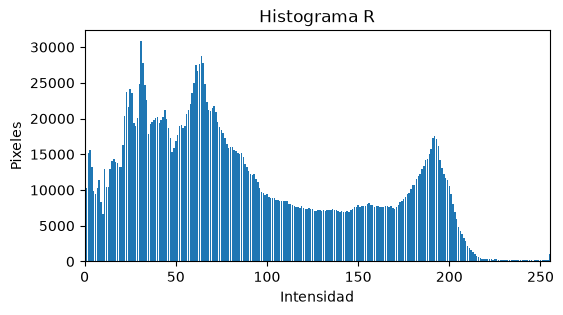

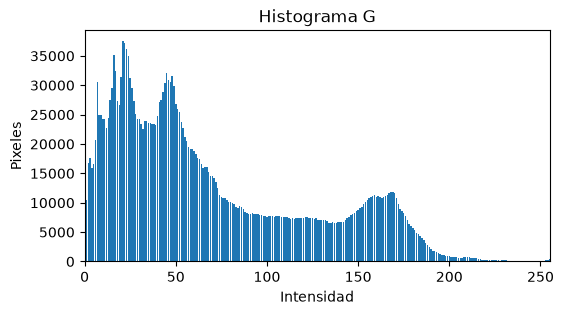

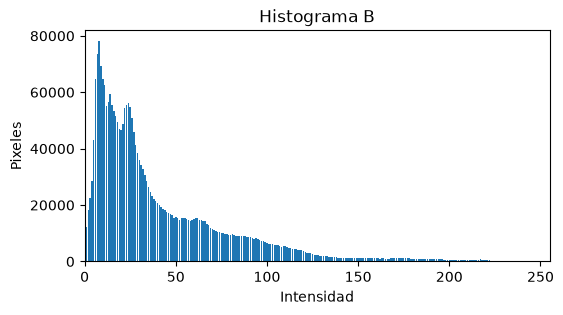

In [20]:
# alternativa
# FASE 2: Histogramas por canal con PIL.histogram()
hist_r = img_rgb.getchannel("R").histogram()
hist_g = img_rgb.getchannel("G").histogram()
hist_b = img_rgb.getchannel("B").histogram()

plt.figure(figsize=(6,3))
plt.bar(range(256), hist_r); plt.title("Histograma R"); plt.xlim(0,255); plt.xlabel("Intensidad"); plt.ylabel("Pixeles"); plt.show()

plt.figure(figsize=(6,3))
plt.bar(range(256), hist_g); plt.title("Histograma G"); plt.xlim(0,255); plt.xlabel("Intensidad"); plt.ylabel("Pixeles"); plt.show()

plt.figure(figsize=(6,3))
plt.bar(range(256), hist_b); plt.title("Histograma B"); plt.xlim(0,255); plt.xlabel("Intensidad"); plt.ylabel("Pixeles"); plt.show()


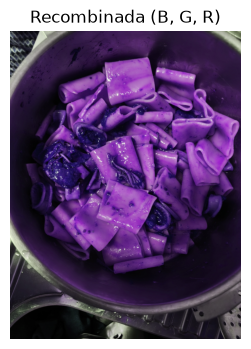

In [26]:
# FASE 3: Recombinar canales desordenados (B, G, R) para observar cambios

from PIL import Image
recombined = Image.merge("RGB", (g, b, r))
plt.figure(figsize=(4,4))
plt.imshow(recombined)
plt.title("Recombinada (B, G, R)")
plt.axis("off")
plt.show()

## Bloque 3 — Transformaciones: resize, crop, rotate, flip

In [27]:
# FASE 1: Inspeccionar tamaño y preparar variables

w, h = img_rgb.size
print("w, h =", w, h)

w, h = 1429 1905


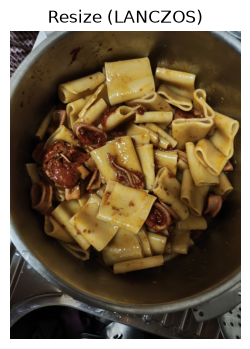

In [5]:
# FASE 2: Resize (a 1/3) con LANCZOS

from PIL import Image
import matplotlib.pyplot as plt
img_color = Image.open ("./pasta.jpg")
img_rgb = img_color.convert("RGB")
w, h = img_rgb.size
thumb = img_rgb.resize((w//3, h//3), Image.Resampling.LANCZOS)
plt.figure(figsize=(4,4)); plt.imshow(thumb); plt.title("Resize (LANCZOS)"); plt.axis("off"); plt.show()


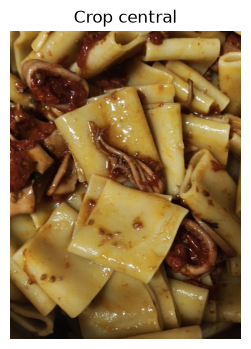

In [29]:
# FASE 3: Crop (zona central)

left, top, right, bottom = int(w*0.25), int(h*0.25), int(w*0.75), int(h*0.75)
crop = img_rgb.crop((left, top, right, bottom))
plt.figure(figsize=(4,4)); plt.imshow(crop); plt.title("Crop central"); plt.axis("off"); plt.show()


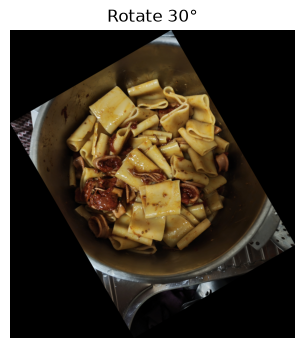

In [30]:
# FASE 4: Rotate 30 grados (expand=True) con BICUBIC

rot = img_rgb.rotate(30, expand=True, resample=Image.Resampling.BICUBIC)
plt.figure(figsize=(4,4)); plt.imshow(rot); plt.title("Rotate 30°"); plt.axis("off"); plt.show()


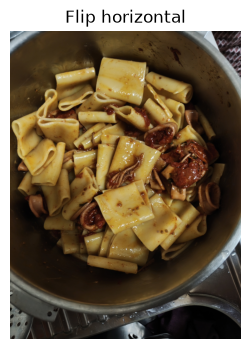

In [31]:
# FASE 5: Flip horizontal

flip_h = img_rgb.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
plt.figure(figsize=(4,4)); plt.imshow(flip_h); plt.title("Flip horizontal"); plt.axis("off"); plt.show()


## Bloque 4 — Filtros y ajustes (ImageFilter, ImageEnhance)

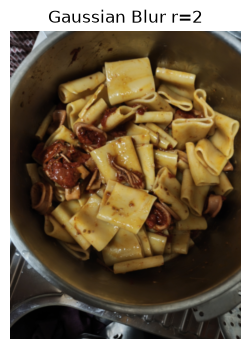

In [6]:
# FASE 1: Desenfoque gaussiano

from PIL import Image
import matplotlib.pyplot as plt
img_color = Image.open ("./pasta.jpg")
img_rgb = img_color.convert("RGB")
from PIL import ImageFilter, ImageEnhance
blur = img_rgb.filter(ImageFilter.GaussianBlur(radius=2))
plt.figure(figsize=(4,4)); plt.imshow(blur); plt.title("Gaussian Blur r=2"); plt.axis("off"); plt.show()


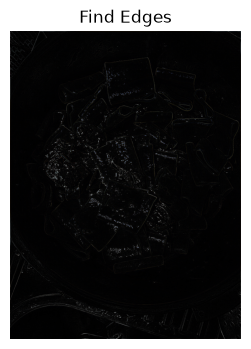

In [7]:
# FASE 2: Deteccion de bordes

edges = img_rgb.filter(ImageFilter.FIND_EDGES)
plt.figure(figsize=(4,4)); plt.imshow(edges); plt.title("Find Edges"); plt.axis("off"); plt.show()


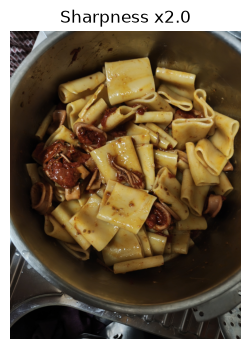

In [8]:
# FASE 3: Nitidez (x2.0)

sharp = ImageEnhance.Sharpness(img_rgb).enhance(2.0)
plt.figure(figsize=(4,4)); plt.imshow(sharp); plt.title("Sharpness x2.0"); plt.axis("off"); plt.show()


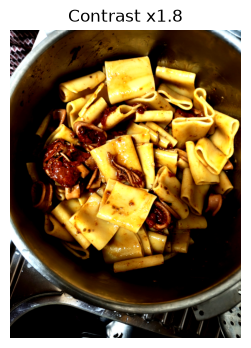

In [9]:
# FASE 4: Contraste (x1.8)

high_contrast = ImageEnhance.Contrast(img_rgb).enhance(1.8)
plt.figure(figsize=(4,4)); plt.imshow(high_contrast); plt.title("Contrast x1.8"); plt.axis("off"); plt.show()


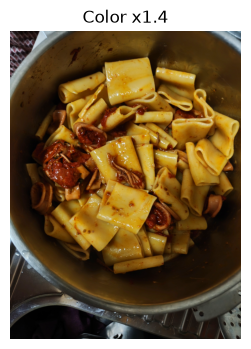

In [10]:
# FASE 5: Color (saturacion x1.4)
rich_color = ImageEnhance.Color(img_rgb).enhance(1.4)
plt.figure(figsize=(4,4)); plt.imshow(rich_color); plt.title("Color x1.4"); plt.axis("off"); plt.show()

## Bloque 5 — ImageOps: equalize, autocontrast, posterize, solarize

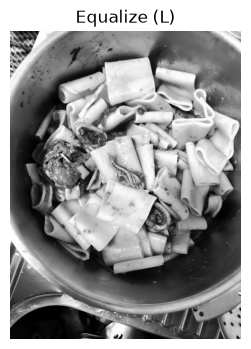

In [11]:
# FASE 1: Equalize en gris
from PIL import ImageOps
gray = img_rgb.convert("L")
eq = ImageOps.equalize(gray)
plt.figure(figsize=(4,4)); plt.imshow(eq, cmap="gray"); plt.title("Equalize (L)"); plt.axis("off"); plt.show()


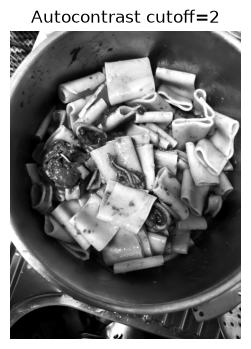

In [12]:
# FASE 2: Auto-contrast con cutoff

auto = ImageOps.autocontrast(gray, cutoff=2)
plt.figure(figsize=(4,4)); plt.imshow(auto, cmap="gray"); plt.title("Autocontrast cutoff=2"); plt.axis("off"); plt.show()


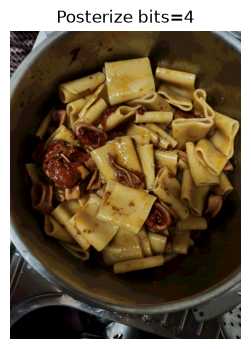

In [13]:
# FASE 3: Posterize (bits=4)
post = ImageOps.posterize(img_rgb, bits=4)
plt.figure(figsize=(4,4)); plt.imshow(post); plt.title("Posterize bits=4"); plt.axis("off"); plt.show()



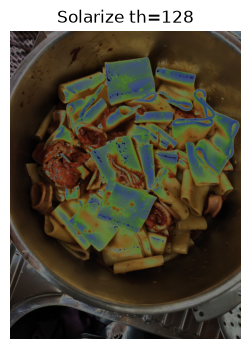

In [14]:
# FASE 4: Solarize (threshold=128)

sol = ImageOps.solarize(img_rgb, threshold=128)
plt.figure(figsize=(4,4)); plt.imshow(sol); plt.title("Solarize th=128"); plt.axis("off"); plt.show()


## Bloque 6 — Mascaras y composite (sin NumPy)

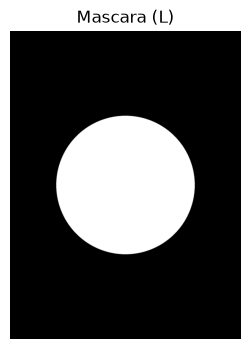

In [15]:
# FASE 1: Crear mascara circular en modo 'L'

from PIL import ImageDraw
mask = Image.new("L", img_rgb.size, color=0)
draw = ImageDraw.Draw(mask)
w, h = img_rgb.size
cx, cy = w//2, h//2
radius = int(min(cx, cy)*0.6)
box = (cx - radius, cy - radius, cx + radius, cy + radius)
draw.ellipse(box, fill=255)
plt.figure(figsize=(4,4)); plt.imshow(mask, cmap="gray"); plt.title("Mascara (L)"); plt.axis("off"); plt.show()


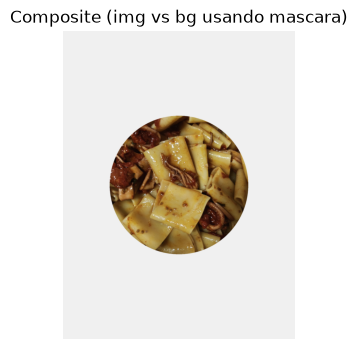

In [16]:
# FASE 2: Composite con fondo gris

bg = Image.new("RGB", img_rgb.size, (240, 240, 240))
cut = Image.composite(img_rgb, bg, mask)
plt.figure(figsize=(4,4)); plt.imshow(cut); plt.title("Composite (img vs bg usando mascara)"); plt.axis("off"); plt.show()


## Bloque 7 — Anotaciones (cajas y texto) con PIL y Matplotlib

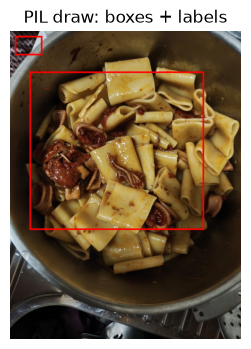

In [25]:
# FASE 1: Dibujar rectangulos y texto con PIL

from PIL import ImageDraw, ImageFont
ann = img_rgb.copy()
draw = ImageDraw.Draw(ann)
font = ImageFont.load_default()
boxes = [(30, 30, 200, 150), (120, 250, 1200, 1230)]
for i, (x1, y1, x2, y2) in enumerate(boxes, start=1):
    draw.rectangle([x1, y1, x2, y2], outline=(255,0,0), width=10)
    draw.text((x1+100, y1+100), f"obj-{i}", fill=(255,0,0), font=font)
plt.figure(figsize=(4,4)); plt.imshow(ann); plt.title("PIL draw: boxes + labels"); plt.axis("off"); plt.show()


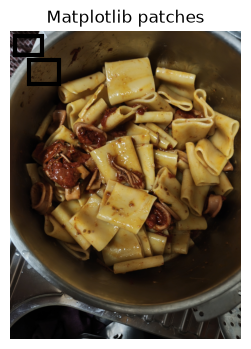

In [26]:
# FASE 2: Anotar con Matplotlib (patches.Rectangle)

import matplotlib.patches as patches
fig, ax = plt.subplots(figsize=(4,4))
ax.imshow(img_rgb); ax.set_title("Matplotlib patches"); ax.axis("off")
for (x1,y1,x2,y2) in [(30,30,200,150),(120,180,300,330)]:
    rect = patches.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, linewidth=3)
    ax.add_patch(rect)
plt.show()

## Bloque 8 — Perfil de intensidad (fila central) sin NumPy

In [28]:
# FASE 1: Extraer una fila (1 pixel de alto) y leer intensidades
gray = img_rgb.convert("L")
w, h = gray.size
y = h//2
print(w,h,y)
row_img = gray.crop((0, y, w, y+1))
row_values = list(row_img.getdata())
print("Pixeles en fila:", len(row_values), "| y =", y)


1429 1905 952
Pixeles en fila: 1429 | y = 952


C:\Users\Asus\AppData\Local\Temp\ipykernel_13692\1706053941.py:7: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  row_values = list(row_img.getdata())


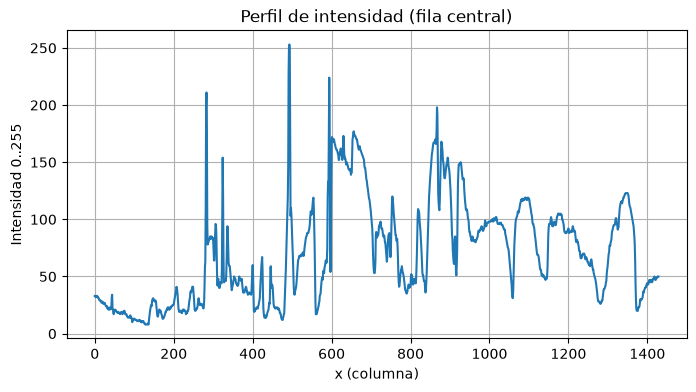

In [29]:
# FASE 2: Graficar el perfil (x = columna, y = intensidad 0..255)
plt.figure(figsize=(8,4))
plt.plot(range(len(row_values)), row_values)
plt.title("Perfil de intensidad (fila central)")
plt.xlabel("x (columna)"); plt.ylabel("Intensidad 0..255")
plt.grid(True)
plt.show()


## Bloque 9 — Guardado y compresion (PNG vs JPEG)

In [30]:
# FASE 1: Guardar copias (no sobreescribir original)
img_rgb.save("salida.png", optimize=True)
img_rgb.save("salida_q80.jpg", quality=80, subsampling="4:2:0", optimize=True)
img_rgb.save("salida_q95.jpg", quality=95, subsampling="4:4:4", optimize=True)
print("Generados: salida.png, salida_q80.jpg, salida_q95.jpg")

Generados: salida.png, salida_q80.jpg, salida_q95.jpg
